In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pss6e1-artifacts/org_pred_lr.pkl
/kaggle/input/pss6e1-artifacts/test_pred_lr.pkl
/kaggle/input/pss6e1-artifacts/oof_pred_lr.pkl
/kaggle/input/pss6e1-artifacts/lr_models.pkl
/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv
/kaggle/input/pss6e1-linear/org_pred_lr.pkl
/kaggle/input/pss6e1-linear/__results__.html
/kaggle/input/pss6e1-linear/test_pred_lr.pkl
/kaggle/input/pss6e1-linear/__notebook__.ipynb
/kaggle/input/pss6e1-linear/oof_pred_lr.pkl
/kaggle/input/pss6e1-linear/__output__.json
/kaggle/input/pss6e1-linear/lr_models.pkl
/kaggle/input/pss6e1-linear/custom.css
/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv


In [2]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00


In [3]:
class CONFIG:
    INPUT_DIR = '/kaggle/input/playground-series-s6e1'

    SEED = 42
    FOLDS = 10
    TARGET = 'exam_score'

config = CONFIG()

In [4]:
train = pd.read_csv(f'{config.INPUT_DIR}/train.csv')
test = pd.read_csv(f'{config.INPUT_DIR}/test.csv')

train_org = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv')
submission = pd.read_csv(f'{config.INPUT_DIR}/sample_submission.csv')

train['source'] = 'train'
test['source'] = 'test'
train_org['source'] = 'original'

cols = train.columns
cols = [col for col in cols if col not in ['id', 'student_id']]

test[config.TARGET] = np.nan

train = train[cols].copy()
test = test[cols].copy()
train_org = train_org[cols].copy()

combine = pd.concat([train_org, train, test], axis=0, ignore_index=True)


<Axes: xlabel='exam_score', ylabel='Count'>

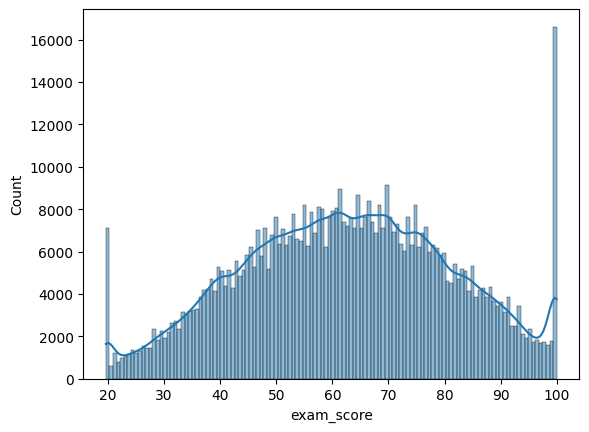

In [5]:
import seaborn as sns
sns.histplot(train[config.TARGET], kde=True)

In [6]:
FEATURES = [col for col in cols if col not in [config.TARGET, 'source']]
CATS = combine[FEATURES].select_dtypes(include='object').columns.to_list()
CATS = [col for col in CATS if col not in ['source']]
NUMS = combine[FEATURES].select_dtypes(include=['int64', 'float64']).columns.to_list()

for df in [combine]:
    for col in NUMS:
        if df[col].dtype=='int64':
            df[col] = df[col].astype('int32')
        else:
            df[col] = df[col].astype('float32')

combine[CATS] = combine[CATS].astype('category')

In [7]:
def preprocess(df):
    df_temp = df.copy()
    eps = 1e-5

    # ================
    # BASIC POLYS
    # ================
    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    # extra polys (tambahan)
    df_temp['study_hours_quartic'] = df_temp['study_hours'] ** 4
    df_temp['class_attendance_cubed'] = df_temp['class_attendance'] ** 3
    df_temp['sleep_hours_cubed'] = df_temp['sleep_hours'] ** 3
    df_temp['age_cubed'] = df_temp['age'] ** 3

    # ================
    # SAFE LOG/SQRT
    # ================
    sh_pos = df_temp['study_hours'].clip(lower=0)
    ca_pos = df_temp['class_attendance'].clip(lower=0)
    sl_pos = df_temp['sleep_hours'].clip(lower=0)
    ag_pos = df_temp['age'].clip(lower=0)

    df_temp['log_study_hours'] = np.log1p(sh_pos)
    df_temp['log_class_attendance'] = np.log1p(ca_pos)
    df_temp['log_sleep_hours'] = np.log1p(sl_pos)

    df_temp['sqrt_study_hours'] = np.sqrt(sh_pos)
    df_temp['sqrt_class_attendance'] = np.sqrt(ca_pos)

    # extra transforms
    df_temp['inv_sleep'] = 1.0 / (sl_pos + 1.0)
    df_temp['inv_study'] = 1.0 / (sh_pos + 1.0)
    df_temp['inv_attendance'] = 1.0 / (ca_pos + 1.0)

    # bounded transforms (stabil)
    df_temp['study_tanh'] = np.tanh(df_temp['study_hours'] / 10.0)
    df_temp['sleep_tanh'] = np.tanh(df_temp['sleep_hours'] / 10.0)
    df_temp['attendance_tanh'] = np.tanh(df_temp['class_attendance'] / 100.0)

    df_temp['study_sigmoid'] = 1.0 / (1.0 + np.exp(-(df_temp['study_hours'] - 5.0)))
    df_temp['sleep_sigmoid'] = 1.0 / (1.0 + np.exp(-(df_temp['sleep_hours'] - 7.0)))
    df_temp['attendance_sigmoid'] = 1.0 / (1.0 + np.exp(-(df_temp['class_attendance'] - 85.0) / 8.0))

    # ================
    # INTERACTIONS (yang kamu punya + tambah)
    # ================
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # interactions tambahan
    df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']
    df_temp['age_times_sleep_hours'] = df_temp['age'] * df_temp['sleep_hours']

    # centered interactions (kadang membantu)
    df_temp['study_center_5'] = df_temp['study_hours'] - 5.0
    df_temp['sleep_center_7'] = df_temp['sleep_hours'] - 7.0
    df_temp['att_center_85'] = df_temp['class_attendance'] - 85.0
    df_temp['study_center_sq'] = df_temp['study_center_5'] ** 2
    df_temp['sleep_center_sq'] = df_temp['sleep_center_7'] ** 2
    df_temp['att_center_sq'] = df_temp['att_center_85'] ** 2

    # ================
    # RATIOS (yang kamu punya + tambah)
    # ================
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    # ratios tambahan
    df_temp['attendance_over_study'] = df_temp['class_attendance'] / (df_temp['study_hours'] + eps)
    df_temp['sleep_over_study'] = df_temp['sleep_hours'] / (df_temp['study_hours'] + eps)
    df_temp['study_over_age'] = df_temp['study_hours'] / (df_temp['age'] + eps)
    df_temp['attendance_over_age'] = df_temp['class_attendance'] / (df_temp['age'] + eps)

    # ================
    # CLIPPED + GAPS
    # ================
    df_temp['study_hours_clip'] = df_temp['study_hours'].clip(0, 12)
    df_temp['sleep_hours_clip'] = df_temp['sleep_hours'].clip(0, 12)
    df_temp['attendance_clip'] = df_temp['class_attendance'].clip(0, 100)

    df_temp['sleep_gap_8'] = (df_temp['sleep_hours'] - 8.0).abs()
    df_temp['sleep_gap_7'] = (df_temp['sleep_hours'] - 7.0).abs()
    df_temp['attendance_gap_100'] = (df_temp['class_attendance'] - 100.0).abs()
    df_temp['attendance_gap_90'] = (df_temp['class_attendance'] - 90.0).abs()
    df_temp['study_gap_6'] = (df_temp['study_hours'] - 6.0).abs()
    df_temp['study_gap_8'] = (df_temp['study_hours'] - 8.0).abs()

    # ================
    # BINS (numerik sederhana)
    # ================
    df_temp["age_bin_num"] = pd.cut(df_temp["age"], bins=[0,17,19,21,23,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["study_bin_num"] = pd.cut(df_temp["study_hours"], bins=[-1,2,4,6,8,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["sleep_bin_num"] = pd.cut(df_temp["sleep_hours"], bins=[-1,5,6,7,8,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["attendance_bin_num"] = pd.cut(df_temp["class_attendance"], bins=[-1,60,75,85,95,101], labels=[0,1,2,3,4]).astype(float)

    # ================
    # ORDINAL ENCODING (FIX: moderate)
    # ================
    sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    facility_rating_map = {'low': 0, 'medium': 1, 'high': 2}
    exam_difficulty_map = {'easy': 0, 'moderate': 1, 'hard': 2}

    df_temp['sleep_quality_numeric'] = df_temp['sleep_quality'].map(sleep_quality_map).fillna(1).astype(int)
    df_temp['facility_rating_numeric'] = df_temp['facility_rating'].map(facility_rating_map).fillna(1).astype(int)
    df_temp['exam_difficulty_numeric'] = df_temp['exam_difficulty'].map(exam_difficulty_map).fillna(1).astype(int)

    # interaksi ordinal dengan numerik
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality_numeric']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating_numeric']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty_numeric']

    # ordinal cross
    df_temp['facility_x_sleepq'] = df_temp['facility_rating_numeric'] * df_temp['sleep_quality_numeric']
    df_temp['difficulty_x_facility'] = df_temp['exam_difficulty_numeric'] * df_temp['facility_rating_numeric']
    df_temp['difficulty_x_sleepq'] = df_temp['exam_difficulty_numeric'] * df_temp['sleep_quality_numeric']

    # ================
    # FLAGS (rule-like)
    # ================
    df_temp["high_att_low_sleep"] = ((df_temp["class_attendance"] >= 90) & (df_temp["sleep_hours"] <= 6)).astype(int)
    df_temp["high_att_high_study"] = ((df_temp["class_attendance"] >= 90) & (df_temp["study_hours"] >= 6)).astype(int)
    df_temp["low_att_high_study"] = ((df_temp["class_attendance"] <= 60) & (df_temp["study_hours"] >= 7)).astype(int)
    df_temp["ideal_sleep_flag"] = ((df_temp["sleep_hours"] >= 7) & (df_temp["sleep_hours"] <= 9)).astype(int)
    df_temp["short_sleep_flag"] = (df_temp["sleep_hours"] <= 5.5).astype(int)
    df_temp["high_study_flag"] = (df_temp["study_hours"] >= 7).astype(int)

    # ================
    # COMPOSITE
    # ================
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)

    df_temp["efficiency2"] = (
        (df_temp["study_hours_clip"] * df_temp["attendance_clip"]) / (df_temp["sleep_hours_clip"] + 1)
    )

    df_temp["weighted_sum"] = (
        0.06 * df_temp["class_attendance"] +
        2.0  * df_temp["study_hours"] +
        1.2  * df_temp["sleep_hours"]
    )

    df_temp["weighted_sum_x_difficulty"] = df_temp["weighted_sum"] * (1.0 + 0.2 * df_temp["exam_difficulty_numeric"])

    # ------------------------
    # list numeric features
    # ------------------------
    numeric_features = [
        # original + extra polys
        'study_hours_squared', 'study_hours_cubed', 'study_hours_quartic',
        'class_attendance_squared', 'class_attendance_cubed',
        'sleep_hours_squared', 'sleep_hours_cubed',
        'age_squared', 'age_cubed',

        # transforms
        'log_study_hours', 'log_class_attendance', 'log_sleep_hours',
        'sqrt_study_hours', 'sqrt_class_attendance',
        'inv_sleep', 'inv_study', 'inv_attendance',
        'study_tanh', 'sleep_tanh', 'attendance_tanh',
        'study_sigmoid', 'sleep_sigmoid', 'attendance_sigmoid',

        # interactions
        'study_hours_times_attendance', 'study_hours_times_sleep', 'attendance_times_sleep',
        'age_times_study_hours', 'age_times_attendance', 'age_times_sleep_hours',
        'study_center_5', 'sleep_center_7', 'att_center_85',
        'study_center_sq', 'sleep_center_sq', 'att_center_sq',

        # ratios
        'study_hours_over_sleep', 'attendance_over_sleep',
        'attendance_over_study', 'sleep_over_study',
        'study_over_age', 'attendance_over_age',

        # clipped + gaps
        'study_hours_clip', 'sleep_hours_clip', 'attendance_clip',
        'sleep_gap_8', 'sleep_gap_7',
        'attendance_gap_100', 'attendance_gap_90',
        'study_gap_6', 'study_gap_8',

        # bins
        'age_bin_num', 'study_bin_num', 'sleep_bin_num', 'attendance_bin_num',

        # ordinal + interactions
        'sleep_quality_numeric', 'facility_rating_numeric', 'exam_difficulty_numeric',
        'study_hours_times_sleep_quality', 'attendance_times_facility', 'sleep_hours_times_difficulty',
        'facility_x_sleepq', 'difficulty_x_facility', 'difficulty_x_sleepq',

        # flags
        'high_att_low_sleep', 'high_att_high_study', 'low_att_high_study',
        'ideal_sleep_flag', 'short_sleep_flag', 'high_study_flag',

        # # composite
        'efficiency', 'efficiency2',
        'weighted_sum', 'weighted_sum_x_difficulty'
    ]

    return df_temp, numeric_features

combine, ARTIFICIAL_FEATURES = preprocess(combine)

In [8]:
CATS1 = []

for c in NUMS:
    n = f'{c}_cat'
    for df in [combine]:
        df[n] = df[c].astype('category')
        print(df[n].dtype)

    CATS1.append(n)

for c in CATS1:
    combine[c] = combine[c].cat.codes.astype('int32')  
    combine[c] = combine[c].astype('category')         
print(CATS1)

category
category
category
category
['age_cat', 'study_hours_cat', 'class_attendance_cat', 'sleep_hours_cat']


In [9]:
CATS2 = []
SIZES = {}

for c in CATS+CATS1:
    n = f'{c}_enc'
    for df in [combine]:
        # df[c] = df[c].astype('category')
        df[n], _ = df[c].factorize()
        df[n] = df[n].astype('int32')
        s = df[n].max()+1

    CATS2.append(n)
    SIZES[n] = s

print(CATS2)
print('='*30)
print(SIZES)

['gender_enc', 'course_enc', 'internet_access_enc', 'sleep_quality_enc', 'study_method_enc', 'facility_rating_enc', 'exam_difficulty_enc', 'age_cat_enc', 'study_hours_cat_enc', 'class_attendance_cat_enc', 'sleep_hours_cat_enc']
{'gender_enc': 3, 'course_enc': 7, 'internet_access_enc': 2, 'sleep_quality_enc': 3, 'study_method_enc': 5, 'facility_rating_enc': 3, 'exam_difficulty_enc': 3, 'age_cat_enc': 8, 'study_hours_cat_enc': 794, 'class_attendance_cat_enc': 631, 'sleep_hours_cat_enc': 70}


In [10]:
ROUND = []
rounding_levels = {'1s':0, '10s':-1}

for c in ['study_hours', 'class_attendance', 'sleep_hours']:
    for suffix, level in rounding_levels.items():
        n = f'{c}_ROUND_{suffix}'
        ROUND.append(n)
        for df in [combine]:
            df[n] = df[c].round(level).astype('int32')

print(len(ROUND))

6


In [11]:
from itertools import combinations

INTER = []

for i, (col1, col2) in enumerate(combinations(CATS1, 2)):
    n = f'{col1}_{col2}'
    if i%5==0: print(i, end='-'*3)
    for df in [combine]:
        combine[n] = (combine[col1].astype(str) + '_' + combine[col2].astype(str)).astype('category')

    INTER.append(n)

print(INTER)
print('='*30)
print('INTER LENGTH :', len(INTER))

0---5---['age_cat_study_hours_cat', 'age_cat_class_attendance_cat', 'age_cat_sleep_hours_cat', 'study_hours_cat_class_attendance_cat', 'study_hours_cat_sleep_hours_cat', 'class_attendance_cat_sleep_hours_cat']
INTER LENGTH : 6


In [12]:
INTER1 = []

for col1, col2 in combinations(CATS2, 2):
    n = f'{col1}_{col2}'
    for df in [combine]:
        df[n] = df[col1]*SIZES[col2] + df[col2]
    INTER1.append(n)

print(len(INTER1))
print('='*30)
print(INTER1)

55
['gender_enc_course_enc', 'gender_enc_internet_access_enc', 'gender_enc_sleep_quality_enc', 'gender_enc_study_method_enc', 'gender_enc_facility_rating_enc', 'gender_enc_exam_difficulty_enc', 'gender_enc_age_cat_enc', 'gender_enc_study_hours_cat_enc', 'gender_enc_class_attendance_cat_enc', 'gender_enc_sleep_hours_cat_enc', 'course_enc_internet_access_enc', 'course_enc_sleep_quality_enc', 'course_enc_study_method_enc', 'course_enc_facility_rating_enc', 'course_enc_exam_difficulty_enc', 'course_enc_age_cat_enc', 'course_enc_study_hours_cat_enc', 'course_enc_class_attendance_cat_enc', 'course_enc_sleep_hours_cat_enc', 'internet_access_enc_sleep_quality_enc', 'internet_access_enc_study_method_enc', 'internet_access_enc_facility_rating_enc', 'internet_access_enc_exam_difficulty_enc', 'internet_access_enc_age_cat_enc', 'internet_access_enc_study_hours_cat_enc', 'internet_access_enc_class_attendance_cat_enc', 'internet_access_enc_sleep_hours_cat_enc', 'sleep_quality_enc_study_method_enc', '

In [13]:
# CATS3 = []
# for col in INTER1:
#     n = f'{col}_cat'
#     for df in [combine]:
#         combine[n] = combine[col].astype('category')
    
#     CATS3.append(n)

# print(len(CATS1))
# print('='*30)

In [14]:
train_idx = combine['source'] == 'train'
test_idx = combine['source'] == 'test'
train_org_idx = combine['source'] == 'original'

train_n = combine[train_idx].reset_index(drop=True).copy()
test_n = combine[test_idx].reset_index(drop=True).copy()
train_org_n = combine[train_org_idx].reset_index(drop=True).copy()

In [15]:
def lin_target(df):
    df_temp = df.copy()

    df_temp['lin_target'] = (
        5.9051154511950499 * df_temp['study_hours'] + 
        0.34540967058057986 * df_temp['class_attendance'] + 
        1.423461171860262 * df_temp['sleep_hours'] + 4.7819
    )

    return df_temp  

train_n = lin_target(train_n)
test_n = lin_target(test_n)
train_org_n = lin_target(train_org_n)

In [16]:
BINS = []
q_list = [10, 20, 30]

for col in NUMS:
    for q in q_list:
        n = f'{col}_bin{q}'

        _, bins = pd.qcut(
            train_org_n[col], q=q, retbins=True, labels=False,
            duplicates='drop'
        )

        train_org_n[n] = pd.cut(train_org_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)
        train_n[n] = pd.cut(train_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)
        test_n[n] = pd.cut(test_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)

        BINS.append(n)

print(f"{len(BINS)} k-bins discretization features created")

12 k-bins discretization features created


In [17]:
TE = []
TE1 = []

for c in CATS+CATS1+BINS:
    for target in [config.TARGET]:
        tmp_mean = train_org_n.groupby(c)[target].mean()
        tmp_median = train_org_n.groupby(c)[target].median()
        tmp_std = train_org_n.groupby(c)[target].std()
        tmp_min = train_org_n.groupby(c)[target].min()
        tmp_max = train_org_n.groupby(c)[target].max()
        # tmp_count = train_org_n.groupby(c)[config.TARGET].size()

        n_mean = f'TE_{c}_mean_{target}'
        n_median = f'TE_{c}_median_{target}'
        n_std = f'TE_{c}_std_{target}'
        n_min = f'TE_{c}_min_{target}'
        n_max = f'TE_{c}_max_{target}'

        # n_c = f'TE_{c}_count'
        print(f'{n_mean}, {n_median}, {n_std}, {n_min}, {n_max}', end=' ')
        tmp_mean.name = n_mean
        tmp_median.name = n_median
        tmp_std.name = n_std
        tmp_min.name = n_min
        tmp_max.name = n_max
    
        stats = (pd.concat([tmp_mean, tmp_median, tmp_std, tmp_min, tmp_max], axis=1).reset_index().rename(columns={'index': c}))
        train_org_n = train_org_n.merge(stats, on=c, how='left')
        train_n = train_n.merge(stats, on=c, how='left')
        test_n = test_n.merge(stats, on=c, how='left')

        if target==config.TARGET:
            TE.append(n_mean)
            # TE.append(n_median)
            TE.append(n_std)
            TE.append(n_min)
            TE.append(n_max)

        else:
            TE1.append(n_mean)
            # TE.append(n_median)
            # TE1.append(n_std)
            # TE1.append(n_min)
            # TE1.append(n_max)   
    # TE.append(n_c)

print('\n',)
print(len(TE))
print(len(TE1))

TE_gender_mean_exam_score, TE_gender_median_exam_score, TE_gender_std_exam_score, TE_gender_min_exam_score, TE_gender_max_exam_score TE_course_mean_exam_score, TE_course_median_exam_score, TE_course_std_exam_score, TE_course_min_exam_score, TE_course_max_exam_score TE_internet_access_mean_exam_score, TE_internet_access_median_exam_score, TE_internet_access_std_exam_score, TE_internet_access_min_exam_score, TE_internet_access_max_exam_score TE_sleep_quality_mean_exam_score, TE_sleep_quality_median_exam_score, TE_sleep_quality_std_exam_score, TE_sleep_quality_min_exam_score, TE_sleep_quality_max_exam_score TE_study_method_mean_exam_score, TE_study_method_median_exam_score, TE_study_method_std_exam_score, TE_study_method_min_exam_score, TE_study_method_max_exam_score TE_facility_rating_mean_exam_score, TE_facility_rating_median_exam_score, TE_facility_rating_std_exam_score, TE_facility_rating_min_exam_score, TE_facility_rating_max_exam_score TE_exam_difficulty_mean_exam_score, TE_exam_dif

In [18]:
# TE = []
# TE1 = []

# for c in CATS+CATS1+BINS+INTER:
#     tmp_mean = train_org_n.groupby(c)[config.TARGET].mean()
#     tmp_median = train_org_n.groupby(c)[config.TARGET].median()
#     tmp_std = train_org_n.groupby(c)[config.TARGET].std()
#     tmp_min = train_org_n.groupby(c)[config.TARGET].min()
#     tmp_max = train_org_n.groupby(c)[config.TARGET].max()
#     # tmp_count = train_org_n.groupby(c)[config.TARGET].size()

#     n_mean = f'TE_{c}_mean'
#     n_median = f'TE_{c}_median'
#     n_std = f'TE_{c}_std'
#     n_min = f'TE_{c}_min'
#     n_max = f'TE_{c}_max'

#     # n_c = f'TE_{c}_count'
#     print(f'{n_mean}, {n_median}, {n_std}, {n_min}, {n_max}', end=' ')
#     tmp_mean.name = n_mean
#     tmp_median.name = n_median
#     tmp_std.name = n_std
#     tmp_min.name = n_min
#     tmp_max.name = n_max
    
#     stats = (pd.concat([tmp_mean, tmp_median, tmp_std, tmp_min, tmp_max], axis=1).reset_index().rename(columns={'index': c}))
#     train_org_n = train_org_n.merge(stats, on=c, how='left')
#     train_n = train_n.merge(stats, on=c, how='left')
#     test_n = test_n.merge(stats, on=c, how='left')

#     TE.append(n_mean)
#     # TE.append(n_median)
#     TE.append(n_std)
#     TE.append(n_min)
#     TE.append(n_max)
#     # TE.append(n_c)

# print('\n',)
# print(len(TE))

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_encode, target, aggs=['mean'], cv=5, smooth='auto', drop_original=True):
        self.cols_to_encode = cols_to_encode
        self.target = target
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        temp_df = X.copy()
        temp_df['target'] = y

        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}_{self.target}'
                map_series = self.mappings_[col][agg_func]
    
                # 1. map, 2. cast to float, 3. fill NaN
                X_transformed[new_col_name] = (
                    X[col].map(map_series)
                         .astype(float)          # <-- key line
                         .fillna(self.global_stats_[agg_func])
                )
    
        if self.drop_original:                   # typo fixed
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
    
        return X_transformed

    def fit_transform(self, X, y):

        self.fit(X, y)
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[val_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}_{self.target}'

                    fold_global_stats = y_train.agg(agg_func)
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            variance_between = mapping .var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between

                            else:
                                m = 0

                        smoothed_mapping = (counts * mapping + m * fold_global_stats) / (counts + m)

                        encoded_values = X_val[col].map(smoothed_mapping)

                    else:
                        encoded_values = X_val[col].map(mapping)

                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stats)

            X_transformed = X.copy()
            for col in encoded_features.columns:
                X_transformed[col] = encoded_features[col]

            if self.drop_original:
                X_transformed.drop(columns=self.cols_to_encode, inplace=True)

            return X_transformed
                    

In [20]:
def rmse(y, y_val):
    y_array = np.array(y)
    y_val_array = np.array(y_val)
    mse = np.mean((y_array - y_val_array)**2)
    rmse = np.sqrt(mse)
    return rmse

In [21]:
# print(rmse(train_n[config.TARGET], train_n['lin_target']))
# print(rmse(train_org_n[config.TARGET], train_org_n['lin_target']))

In [22]:
# from sklearn.linear_model import RidgeCV
# from sklearn.model_selection import KFold
# from sklearn.preprocessing import StandardScaler

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_pred_lr = np.zeros(len(train_n))
# org_pred_lr = np.zeros(len(train_org_n))
# test_pred_lr = np.zeros(len(test_n))

# fold_rmse_lr = []
# lr_models = []
# FEATURES_LR = TE + NUMS + CATS2
# X_lr = train_n[FEATURES_LR].copy()
# X_org_lr = train_org_n[FEATURES_LR].copy()
# test_n_lr = test_n[FEATURES_LR].copy()
# X_lr = X_lr.fillna(0)
# X_org_lr = X_org_lr.fillna(0)
# test_n_lr = test_n_lr.fillna(0)
# y = train_n[config.TARGET].copy()
# y_org = train_org_n[config.TARGET].copy()
# for fold, (train_idx, val_idx) in enumerate(kf.split(X_lr, y), 1):
#     print(f'CURRENTly FOLD{fold} BEING PROCESSED')
#     X_org_lr_n = X_org_lr.copy()
#     X_train, X_val = X_lr.iloc[train_idx], X_lr.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     X_train = pd.concat([X_train, X_org_lr_n], axis=0)
#     y_train = pd.concat([y_train, y_org], axis=0)

#     # scaler = StandardScaler()
#     # X_train[NUMS] = scaler.fit_transform(X_train[NUMS])
#     # test_n[NUMS] = scaler.transform(test_n[NUMS])
#     # X_org_lr_n[NUMS] = scaler.transform(X_org_lr_n[NUMS])
#     print('TRAINING SHAPE :', X_train.shape)
#     alphas = np.logspace(-3, 3, 20)
#     lr_model = RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error')
#     lr_model.fit(X_train, y_train)
#     lr_models.append(lr_model)

#     lr_val_pred = lr_model.predict(X_val)
#     # lr_test_pred = lr_model.predict(test_n_lr)

#     oof_pred_lr[val_idx] = lr_val_pred
#     org_pred_lr+=(lr_model.predict(X_org_lr)) / config.FOLDS
#     test_pred_lr+=(lr_model.predict(test_n_lr)) / config.FOLDS

#     rmse_lr = rmse(y_val, lr_val_pred)
#     fold_rmse_lr.append(rmse_lr)
#     print(f'Fold {fold} RMSE : {rmse_lr}')


# print('\n OOF RMSE for LR :', np.mean(fold_rmse_lr))

In [23]:
import joblib

oof_pred_lr = joblib.load('/kaggle/input/pss6e1-linear/oof_pred_lr.pkl')
org_pred_lr = joblib.load('/kaggle/input/pss6e1-linear/org_pred_lr.pkl')
test_pred_lr = joblib.load('/kaggle/input/pss6e1-linear/test_pred_lr.pkl')

In [24]:
# FEATURES_N = CATS + CATS1 + CATS2 + NUMS + BINS + ['lr_preds'] + TE + INTER1
# FEATURES_N = CATS + CATS1 + ['lr_preds'] + TE + INTER1 + NUMS 
FEATURES_N = CATS2 + ['lr_preds'] + TE + INTER1 + NUMS + BINS
len(FEATURES_N)
train_n['lr_preds'] = oof_pred_lr
train_org_n['lr_preds'] = org_pred_lr
test_n['lr_preds'] = test_pred_lr
X = train_n[FEATURES_N].copy()
y = train_n[config.TARGET].copy()

X_org = train_org_n[FEATURES_N].copy()
y_org = train_org_n[config.TARGET].copy()

test_n = test_n[FEATURES_N].copy()

In [25]:
# import joblib

# joblib.dump(cols, 'cols.pkl')
# joblib.dump(FEATURES, 'features.pkl')
# joblib.dump(CATS, 'cats.pkl')
# joblib.dump(CATS1, 'cats1.pkl')
# joblib.dump(CATS2, 'cats2.pkl')
# joblib.dump(NUMS, 'nums.pkl')
# joblib.dump(INTER, 'inter.pkl')
# joblib.dump(TE, 'te.pkl')
# joblib.dump(TE1, 'te1.pkl')
# joblib.dump(ARTIFICIAL_FEATURES, 'artificial_features.pkl')
# joblib.dump(config, 'config.pkl')

# train_n.to_csv('train_n.csv', index=False)
# train_org_n.to_csv('train_org_n.csv', index=False)
# test_n.to_csv('test_n.csv', index=False)

In [26]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import KFold
# import gc
# import warnings
# warnings.filterwarnings('ignore')

# params = {
#    'n_estimators': 10000,
#     'learning_rate': 0.007,
#     'max_depth': 7,
#     'subsample': 0.8,
#     'reg_lambda': 3,
#     'colsample_bytree': 0.6,
#     'colsample_bynode': 0.7,
#     'tree_method': 'hist',
#     'random_state': 42,
#     'early_stopping_rounds': 100,
#     'eval_metric': 'rmse',
#     'device': 'cuda',
#     'enable_categorical': True
# }

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_preds = np.zeros(len(X))
# test_preds = np.zeros(len(test_n))


# fold_scores = []
# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#     X_org_n = X_org.copy()
#     y_org_n = y_org.copy()
#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     y_org_n_res, y_train_res, y_val_res = y_org_n - X_org_n['lr_preds'], y_train - X_train['lr_preds'], y_val - X_val['lr_preds']
#     print(f'TRAINING SHAPE BEFORE DUPLICATION: {X_train.shape}')
#     # for i in range(1):
#     #     X_train = pd.concat([X_train, X_train], axis=0)
#     #     y_train = pd.concat([y_train, y_train], axis=0)

#     # for j in range(2):
#     #     X_org_n = pd.concat([X_org_n, X_org_n], axis=0)
#     #     y_org_n = pd.concat([y_org_n, y_org_n], axis=0)
#     # print(f'TRAINING SHAPE AFTER DUPLICATION: {X_train.shape}')
#     X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
#     y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)
#     # y_train_res = pd.concat([y_org_n_res, y_train_res], axis=0, ignore_index=True)
#     # print(f'TRAINING SHAPE :{X_train.shape}')
#     # print(f'VALIDATION SHAPE :{X_val.shape}')
    
#     # X_val = pd.concat([X_val])
#     # print(f'TRAINING SHAPE BEFORE ENCODING :{X_train.shape}')
#     # TE = TargetEncoder(cols_to_encode=CATS+CATS1+BINS, target=config.TARGET, aggs=['mean', 'std', 'min', 'max'], cv=5, smooth='auto', drop_original=False)
#     # X_train = TE.fit_transform(X_train, y_train)
#     # X_val = TE.transform(X_val)
#     # test_enc = TE.transform(test_n)

#     # TE2 = TargetEncoder(cols_to_encode=CATS+CATS1+BINS, target='study_hours', aggs=['mean', 'std', 'min', 'max'], cv=5, smooth='auto', drop_original=False)
#     # X_train = TE2.fit_transform(X_train, X_train['study_hours'])
#     # X_val = TE2.transform(X_val)
#     # test_enc = TE2.transform(test_enc)
#     print(f'TRAINING SHAPE AFTER ENCODING :{X_train.shape}')
#     print(f'LABEL SHAPE AFTER ENCODING :{y_train_res.shape}')
#     model = XGBRegressor(**params)

#     model.fit(X_train, y_train,
#              eval_set=[(X_val, y_val)],
#              verbose=1000)

#     val_preds = model.predict(X_val) 
#     val_preds = np.clip(val_preds, 0, 100)
#     # oof_preds[val_idx] = val_preds
    
#     fold_score = rmse(y_val, val_preds)
#     fold_scores.append(fold_score)
#     print(f'FOLD {fold} RMSE: {fold_score:.4f}')
#     test_preds +=  np.clip(model.predict(test_n), 0, 100)   / config.FOLDS


# overall_rmse = np.mean(fold_scores)
# print('='*30)
# print(f"Overall OOF RMSE: {overall_rmse:.4f}")
# print('='*30)

In [27]:
# submission[config.TARGET] = test_preds
# submission.to_csv(f'submission_{overall_rmse}.csv', index=False)

In [28]:
# imp_n = pd.DataFrame(
#     {
#         'feature_names': model.feature_names_in_,
#         'gain': model.feature_importances_
#     }
# ).sort_values('gain', ascending=False).reset_index(drop=True)

# imp_n.to_csv('xgb_feature_importance.csv', index=False)
# imp_n.head(10)

In [29]:
# import lightgbm as lgb
# from sklearn.model_selection import KFold
# import numpy as np
# import gc
# import warnings
# warnings.filterwarnings('ignore')

# lgb_params = {
#     'objective': 'regression',
#     'metric': 'rmse',
#     'learning_rate': 0.007,
#     'num_leaves': 64,
#     'max_depth': 7,
#     'subsample': 0.8,
#     'colsample_bytree': 0.6,
#     'lambda_l2': 3.0,
#     'n_estimators': 10000,
#     'random_state': 42,
#     'device': 'cpu',
#     'verbosity': -1
# }

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_preds_lgb = np.zeros(len(X))
# test_preds_lgb = np.zeros(len(test_n))
# fold_scores_lgb = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#     print(f'\nFOLD {fold}')

#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     X_org_n = X_org.copy()
#     y_org_n = y_org.copy()

#     X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
#     y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)

#     model = lgb.LGBMRegressor(**lgb_params)

#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         callbacks=[lgb.early_stopping(100)],
#     )

#     val_preds = np.clip(model.predict(X_val), 0, 100)
#     oof_preds_lgb[val_idx] = val_preds

#     fold_rmse = rmse(y_val, val_preds)
#     fold_scores_lgb.append(fold_rmse)
#     print(f'Fold RMSE: {fold_rmse:.4f}')

#     test_preds_lgb += np.clip(
#         model.predict(test_n), 0, 100
#     ) / config.FOLDS

#     gc.collect()

# overall_rmse_lgb = np.mean(fold_scores_lgb)
# print('=' * 40)
# print(f'LIGHTGBM OOF RMSE: {overall_rmse_lgb:.5f}')

# submission[config.TARGET] = test_preds_lgb
# submission.to_csv(f'submission_lgb_{overall_rmse_lgb:.5f}.csv', index=False)


In [30]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.model_selection import KFold
import numpy as np
import gc

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

oof_preds_tab = np.zeros(len(X))
test_preds_tab = np.zeros(len(test_n))
fold_scores_tab = []

X = X.fillna(0)
X_org = X_org.fillna(0)
test_n = test_n.fillna(0)

X_np = X.values
y_np = y.values.reshape(-1, 1)
X_org_np = X_org.values
y_org_np = y_org.values.reshape(-1, 1)
test_np = test_n.values

for fold, (train_idx, val_idx) in enumerate(kf.split(X_np, y_np)):
    print(f'\nFOLD {fold}')

    X_train, y_train = X_np[train_idx], y_np[train_idx]
    X_val, y_val = X_np[val_idx], y_np[val_idx]

    X_train = np.vstack([X_org_np, X_train])
    y_train = np.vstack([y_org_np, y_train])

    model = TabNetRegressor(
        n_d=32,
        n_a=32,
        n_steps=5,
        gamma=1.5,
        n_independent=2,
        n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type='entmax',
        device_name=DEVICE
    )

    model.fit(
        X_train=X_train,
        y_train=y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=['rmse'],
        patience=50,
        max_epochs=300,
        batch_size=8192,
        virtual_batch_size=512,
        num_workers=0,
        drop_last=False
    )

    val_preds = np.clip(model.predict(X_val).reshape(-1), 0, 100)
    oof_preds_tab[val_idx] = val_preds

    fold_rmse = rmse(y_val.flatten(), val_preds)
    fold_scores_tab.append(fold_rmse)
    print(f'Fold RMSE: {fold_rmse:.4f}')

    test_preds_tab += np.clip(
        model.predict(test_np).reshape(-1), 0, 100
    ) / config.FOLDS

    gc.collect()

overall_rmse_tab = np.mean(fold_scores_tab)
print('=' * 40)
print(f'TABNET OOF RMSE: {overall_rmse_tab:.5f}')

submission[config.TARGET] = test_preds_tab
submission.to_csv(f'submission_tabnet_{overall_rmse_tab:.5f}.csv', index=False)



FOLD 0
epoch 0  | loss: 699.53358| val_0_rmse: 285.98871|  0:00:12s
epoch 1  | loss: 90.28652| val_0_rmse: 116.73398|  0:00:23s
epoch 2  | loss: 83.55181| val_0_rmse: 32.52373|  0:00:34s
epoch 3  | loss: 80.72671| val_0_rmse: 18.50208|  0:00:45s
epoch 4  | loss: 81.32993| val_0_rmse: 9.80671 |  0:00:56s
epoch 5  | loss: 80.87119| val_0_rmse: 9.92934 |  0:01:08s
epoch 6  | loss: 80.32657| val_0_rmse: 9.00505 |  0:01:19s
epoch 7  | loss: 83.77371| val_0_rmse: 8.90169 |  0:01:30s
epoch 8  | loss: 80.35292| val_0_rmse: 8.81599 |  0:01:41s
epoch 9  | loss: 79.80408| val_0_rmse: 8.80697 |  0:01:52s
epoch 10 | loss: 80.3718 | val_0_rmse: 8.80571 |  0:02:03s
epoch 11 | loss: 79.95866| val_0_rmse: 8.8089  |  0:02:14s
epoch 12 | loss: 79.40923| val_0_rmse: 8.81655 |  0:02:26s
epoch 13 | loss: 79.90287| val_0_rmse: 8.79885 |  0:02:37s
epoch 14 | loss: 79.53798| val_0_rmse: 8.80069 |  0:02:48s
epoch 15 | loss: 79.54413| val_0_rmse: 8.7996  |  0:02:59s
epoch 16 | loss: 79.46226| val_0_rmse: 8.8225